**CSI 4106 Introduction to Artificial Intelligence** <br/>
*Assignment 3: Neural Networks*

# Identification

Name: Kaitlyn Wong<br/>
Student Number: 300201087

Name: Sooriya Radhakrishnan<br/>
Student Number: 300175667

## 1. Exploratory Analysis

### Loading the dataset

A custom dataset has been created for this assignment. It has been made available on a public GitHub repository:

- [github.com/turcotte/csi4106-f24/tree/main/assignments-data/a3](https://github.com/turcotte/csi4106-f24/tree/main/assignments-data/a3)

Access and read the dataset directly from this GitHub repository in your Jupyter notebook.

You can use this code cell for you import statements and other initializations.

In [30]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate
import tensorflow as tf
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, classification_report


In [19]:
source_url = 'https://raw.githubusercontent.com/turcotte/csi4106-f24/refs/heads/main/assignments-data/a3'

dataset_train = pd.read_csv(f'{source_url}/cb513_train.csv', header=None)
dataset_valid = pd.read_csv(f'{source_url}/cb513_valid.csv', header=None)
dataset_test = pd.read_csv(f'{source_url}/cb513_test.csv', header=None)

print(dataset_train.head())

   0       1       2       3       4       5       6       7       8    \
0    2  0.0000  0.0556  0.0000  0.0556  0.1111  0.0000  0.0556  0.0000   
1    2  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
2    2  0.1905  0.0000  0.3333  0.0000  0.0000  0.0000  0.0000  0.0000   
3    2  0.0225  0.0000  0.0112  0.1348  0.0000  0.0112  0.1348  0.0112   
4    2  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   

      9    ...     453     454     455     456     457     458  459     460  \
0  0.0000  ...  0.1667  0.2222  0.0000  0.0000  0.1667  0.0000  0.0  0.0000   
1  0.0000  ...  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0  0.0000   
2  0.2857  ...  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0  0.1905   
3  0.1685  ...  0.0000  0.0787  0.0674  0.0112  0.0225  0.1573  0.0  0.0225   
4  0.0000  ...  0.0000  0.0000  0.0000  0.6667  0.0000  0.0000  0.0  0.0000   

     461  462  
0  0.000  0.0  
1  0.000  0.0  
2  0.381  0.0  
3  0.000  0.0  


### Data Pre-Processing

2. **Shuffling the Rows**:

    - Since examples are generated by sliding a window across each protein sequence, most adjacent examples originate from the same protein and share 20 positions. To mitigate the potential negative impact on model training, the initial step involves shuffling the **rows** of the data matrix.

In [20]:
dataset_train = dataset_train.sample(frac=1, random_state=42)
dataset_valid = dataset_valid.sample(frac=1, random_state=42)
dataset_test = dataset_test.sample(frac=1, random_state=42)

print(dataset_train.head())


       0       1    2       3       4       5       6    7       8       9    \
644      0  0.1667  0.0  0.2500  0.0833  0.0000  0.0000  0.0  0.0000  0.0000   
50314    2  0.1461  0.0  0.0112  0.0000  0.0337  0.0225  0.0  0.0337  0.0112   
5325     0  0.0000  0.0  0.0000  0.0000  0.1250  0.0000  0.0  0.0000  0.5000   
35749    2  0.0000  0.0  0.0000  0.0000  0.2000  0.0000  0.0  0.0000  0.0000   
4805     0  0.0000  0.0  0.0000  0.0000  0.1000  0.0000  0.0  0.4000  0.0000   

       ...     453     454     455     456  457  458  459   460  461  462  
644    ...  0.0000  0.0833  0.0000  0.0000  0.0  0.0  0.0  0.00  0.0  0.0  
50314  ...  0.0112  0.3034  0.3596  0.0225  0.0  0.0  0.0  0.00  0.0  0.0  
5325   ...  0.0000  0.0000  0.0000  0.1250  0.0  0.0  0.0  0.25  0.0  0.0  
35749  ...  0.0000  0.0000  0.0000  0.0000  0.0  0.2  0.0  0.00  0.0  0.0  
4805   ...  0.0000  0.2000  0.1000  0.1000  0.0  0.1  0.0  0.00  0.0  0.0  

[5 rows x 463 columns]


3. **Scaling of Numerical Features**:

    - Since all 462 features are proportions represented as values between 0 and 1, scaling may not be necessary. In our evaluations, using [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) actually degraded model performance. Within your pipeline, compare the effects of not scaling the data versus applying [MinMaxScaler](https://scikit-learn.org/1.5/modules/generated/sklearn.preprocessing.MinMaxScaler.html). In the interest of time, a single experiment will suffice. It is important to note that when scaling is applied, a uniform method should be used across all columns, given their homogeneous nature.

In [21]:

X = dataset_train.drop(columns=0)
y = dataset_train[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LogisticRegression()

lr_model.fit(X_train,y_train)
unscaled_pred = lr_model.predict(X_test)


scaler = MinMaxScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)
lr_model.fit(scaled_X_train, y_train)
scaled_pred = lr_model.predict(scaled_X_test)

unscaled_acc = f1_score(y_test, unscaled_pred, average = 'weighted')
scaled_acc = f1_score(y_test, scaled_pred, average = 'weighted')
print(f"Unscaled F1 Score: {unscaled_acc}")
print(f"Scaled F1 Score: {scaled_acc}")

Unscaled F1 Score: 0.6801539721761699
Scaled F1 Score: 0.6798424977784361


In [22]:
# After applying the minmaxscaler on the data, the f1 score shows that the performance between the scaled and unscaled data is quite minimal. Logistic Regression is a model that usually
# will benefit from using a scaler on the data but here there was not much change. This goes back to the statement in the question that scaling may not be neccessary for this scenario.
# This can also be the cause of having a dataset which is already quite homogenous and where scaling is not required. 

4. **Isolating the Target and the Data**:

    - In the CSV files, the target and data are combined. To prepare for our machine learning experiments, separate the training data $X$ and the target vector $y$ for each of the three datasets.

In [23]:
X_train = dataset_train.drop(columns=0)
y_train = dataset_train[0]

X_test = dataset_test.drop(columns=0)
y_test = dataset_test[0]

X_valid = dataset_valid.drop(columns=0)
y_valid = dataset_valid[0]

print(X_train.head())
print(y_train.head())

          1    2       3       4       5       6    7       8       9    \
644    0.1667  0.0  0.2500  0.0833  0.0000  0.0000  0.0  0.0000  0.0000   
50314  0.1461  0.0  0.0112  0.0000  0.0337  0.0225  0.0  0.0337  0.0112   
5325   0.0000  0.0  0.0000  0.0000  0.1250  0.0000  0.0  0.0000  0.5000   
35749  0.0000  0.0  0.0000  0.0000  0.2000  0.0000  0.0  0.0000  0.0000   
4805   0.0000  0.0  0.0000  0.0000  0.1000  0.0000  0.0  0.4000  0.0000   

          10   ...     453     454     455     456  457  458  459   460  461  \
644    0.0000  ...  0.0000  0.0833  0.0000  0.0000  0.0  0.0  0.0  0.00  0.0   
50314  0.6629  ...  0.0112  0.3034  0.3596  0.0225  0.0  0.0  0.0  0.00  0.0   
5325   0.0000  ...  0.0000  0.0000  0.0000  0.1250  0.0  0.0  0.0  0.25  0.0   
35749  0.6000  ...  0.0000  0.0000  0.0000  0.0000  0.0  0.2  0.0  0.00  0.0   
4805   0.3000  ...  0.0000  0.2000  0.1000  0.1000  0.0  0.1  0.0  0.00  0.0   

       462  
644    0.0  
50314  0.0  
5325   0.0  
35749  0.0  
480

### Model Development & Evaluation

5. **Model Development**:

    - **Dummy Model**: Implement a model utilizing the [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html). This model disregards the input data and predicts the majority class. Such model is sometimes called a straw man model.

    - **Basline Model**: As a baseline model, select one of the previously studied machine learning algorithms: Decision Trees, K-Nearest Neighbors (KNN), or Logistic Regression. Use the default parameters provided by scikit-learn to train each model as a baseline. Why did you choose this particular classifier? Why do you think it should be appropriate for this specific task?

    - **Neural Network Model**: Utilizing [Keras](https://keras.io) and [TensorFlow](https://www.tensorflow.org), construct a sequential model comprising an input layer, a hidden layer, and an output layer. The input layer should consist of 462 nodes, reflecting the 462 attributes of each example. The hidden layer should include 8 nodes and employ the default activation function. The output layer should contain three nodes, corresponding to the three classes: helix (0), sheet (1), and coil (2). Apply the softmax activation function to the output layer to ensure that the outputs are treated as probabilities, with their sum equaling 1 for each training example.

    We therefore have three models: dummy, baseline, and neural network.

In [24]:
# Dummy Model
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train)
dummy_clf.predict(X_train)
dummy_clf.score(X_train, y_train)

0.4114871935633288

In [25]:
# Baseline Model
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_clf.score(X_train, y_train)

0.6950472628707691

In [ ]:
# Neural Network Model
tf.random.set_seed(42)

nnm = tf.keras.Sequential()
nnm.add(tf.keras.layers.InputLayer(shape=[462]))
nnm.add(tf.keras.layers.Dense(8, activation='relu'))
nnm.add(tf.keras.layers.Dense(3, activation='softmax'))
nnm.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

6. **Model Evaluation**:

    - Employ cross-validation to assess the performance of the baseline model. Select a small number of folds to prevent excessive computational demands.

In [27]:
scoring = {
    'precision_score': make_scorer(precision_score, average='weighted'),
    'recall_score': make_scorer(recall_score, average='weighted'),
    'f1_score': make_scorer(f1_score, average='weighted'),
    'accuracy': 'accuracy'
}

num_folds = 5
lr_scores = cross_validate(lr_clf, X_train, y_train, cv=num_folds, scoring=scoring)
print(f"Average Precision for Logistic Regression: {lr_scores['test_precision_score'].mean()}")
print(f"Average Recall for Logistic Regression: {lr_scores['test_recall_score'].mean()}")
print(f"Average F1 Score for Logistic Regression: {lr_scores['test_f1_score'].mean()}")
print(f"Average Accuracy for Logistic Regression: {lr_scores['test_accuracy'].mean()}")

Average Precision for Logistic Regression: 0.6836409313023093
Average Recall for Logistic Regression: 0.6858518805189104
Average F1 Score for Logistic Regression: 0.6826732617576043
Average Accuracy for Logistic Regression: 0.6858518805189104


    - **Training neural networks can be time-consuming.** Consequently, their performance is typically assessed once using a validation set. Make sure to not use the test set until the very end of the assignment.

In [ ]:
nnm.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))
nnm_predictions = nnm.predict(X_valid)

Epoch 1/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 524us/step - accuracy: 0.5693 - loss: 0.9182
Epoch 2/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 491us/step - accuracy: 0.6873 - loss: 0.7471
Epoch 3/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 488us/step - accuracy: 0.6894 - loss: 0.7430
Epoch 4/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 497us/step - accuracy: 0.6900 - loss: 0.7406
Epoch 5/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 533us/step - accuracy: 0.6915 - loss: 0.7386
Epoch 6/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 491us/step - accuracy: 0.6918 - loss: 0.7367
Epoch 7/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 515us/step - accuracy: 0.6931 - loss: 0.7343
Epoch 8/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 493us/step - accuracy: 0.6955 - loss: 0.7301
Epoch 9/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 504us/step - accuracy: 0.6978 - loss: 0.7257
Epoch 10/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 506us/step - accuracy: 0.6988 - loss: 0.7220
Epoch 11/30
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 495us/step - accuracy: 0.6996 - loss: 0.7193
Epoch 12

In [52]:
print(classification_report(y_valid, nnm_predictions.argmax(axis=1)))

              precision    recall  f1-score   support

           0       0.72      0.68      0.70      2490
           1       0.70      0.47      0.56      1808
           2       0.66      0.82      0.73      3111

    accuracy                           0.69      7409
   macro avg       0.69      0.65      0.66      7409
weighted avg       0.69      0.69      0.68      7409



    - Assess the models using metrics such as precision, recall, and F1-score.

### Hyperparameter Optimization

7. **Baseline Model:**

    - To ensure a fair comparison for our baseline model, we will examine how varying hyperparameter values affect its performance. This prevents the erroneous conclusion that neural networks inherently perform better, when in fact, appropriate hyperparameter tuning could enhance the baseline model's performance.

    - Focus on the following relevant hyperparameters for each model:

        - [DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html): `criterion` and `max_depth`.
  
        - [LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html): `penalty`, `max_iter`, and `tol`.
  
        - [KNeighborsClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html): `n_neighbors` and `weights`.

    - Employ a grid search strategy or utilize scikit-learn's built-in methods [GridSearchCV](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html) to thoroughly evaluate all combinations of hyperparameter values. Cross-validation should be used to assess each combination.

    - Quantify the performance of each hyperparameter configuration using precision, recall, and F1-score as metrics.

    - Analyze the findings and offer insights into which hyperparameter configurations achieved optimal performance for each model.

In [ ]:
# Code cell

8. **Neural Network:**

    In our exploration and tuning of neural networks, we focus on the following hyperparameters:

    - **Single hidden layer, varying the number of nodes**. 

        - Start with a single node in the hidden layer. Use a graph to depict the progression of loss and accuracy for both the training and validation sets, with the horizontal axis representing the number of training epochs and the vertical axis showing loss and accuracy. Training this network should be relatively fast, so let's conduct training for 50 epochs. Observing the graph, what do you conclude? Is the network underfitting or overfitting? Why?

        - Repeat the above process using 2 and 4 nodes in the hidden layer. Use the same type of graph to document your observations regarding loss and accuracy.

        - Start with 8 nodes in the hidden layer and progressively double the number of nodes until it surpasses the number of nodes in the input layer. This results in seven experiments and corresponding graphs for the following configurations: 8, 16, 32, 64, 128, 256, and 512 nodes. Document your observations throughout the process.
        
        - Ensure that the **number of training epochs** is adequate for **observing an increase in validation loss**. **Tip**: During model development, start with a small number of epochs, such as 5 or 10. Once the model appears to perform well, test with larger values, like 40 or 80 epochs, which proved reasonable in our tests. Based on your observations, consider conducting further experiments, if needed. How many epochs were ultimately necessary?

In [54]:
def build_model(num_nodes, activation_hidden, activation_output, additional_layers=0):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(shape=[462]))
    for _ in range(additional_layers + 1):
        model.add(tf.keras.layers.Dense(num_nodes, activation=activation_hidden))
    model.add(tf.keras.layers.Dense(3, activation=activation_output))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])
    return model

Epoch 1/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 618us/step - accuracy: 0.4302 - loss: 1.0583 - val_accuracy: 0.5323 - val_loss: 0.9938
Epoch 2/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 542us/step - accuracy: 0.5883 - loss: 0.9341 - val_accuracy: 0.6402 - val_loss: 0.8533
Epoch 3/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 560us/step - accuracy: 0.6605 - loss: 0.8072 - val_accuracy: 0.6597 - val_loss: 0.7960
Epoch 4/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - accuracy: 0.6798 - loss: 0.7628 - val_accuracy: 0.6711 - val_loss: 0.7796
Epoch 5/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 549us/step - accuracy: 0.6873 - loss: 0.7483 - val_accuracy: 0.6751 - val_loss: 0.7738
Epoch 6/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 565us/step - accuracy: 0.6894 - loss: 0.7425 - val_accuracy: 0.6758 - val_loss: 0.7711
Epoch 7/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step - accuracy: 0.6915 - loss: 0.7391 - val_accuracy: 0.6755 - val_loss: 0.7694
Epoch 8/10
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 537us/step - accuracy: 0.6919 -

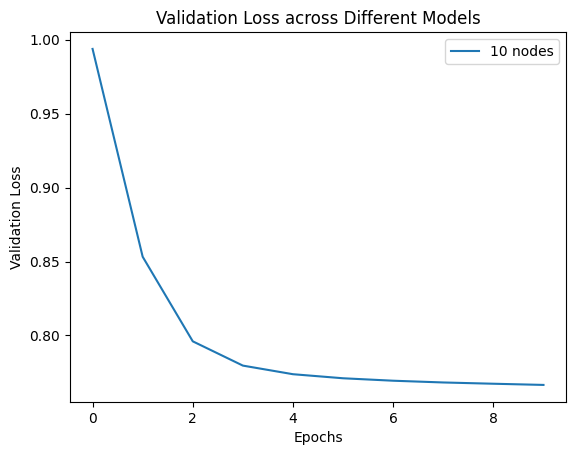

Epoch 1/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 591us/step - accuracy: 0.4469 - loss: 1.0480 - val_accuracy: 0.5713 - val_loss: 0.9505
Epoch 2/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 535us/step - accuracy: 0.6179 - loss: 0.8886 - val_accuracy: 0.6511 - val_loss: 0.8271
Epoch 3/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step - accuracy: 0.6680 - loss: 0.7884 - val_accuracy: 0.6678 - val_loss: 0.7876
Epoch 4/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 565us/step - accuracy: 0.6821 - loss: 0.7571 - val_accuracy: 0.6722 - val_loss: 0.7757
Epoch 5/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 544us/step - accuracy: 0.6877 - loss: 0.7457 - val_accuracy: 0.6740 - val_loss: 0.7714
Epoch 6/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step - accuracy: 0.6895 - loss: 0.7406 - val_accuracy: 0.6746 - val_loss: 0.7694
Epoch 7/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step - accuracy: 0.6909 - loss: 0.7375 - val_accuracy: 0.6744 - val_loss: 0.7682
Epoch 8/25
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 538us/step - accuracy: 0.6931 -

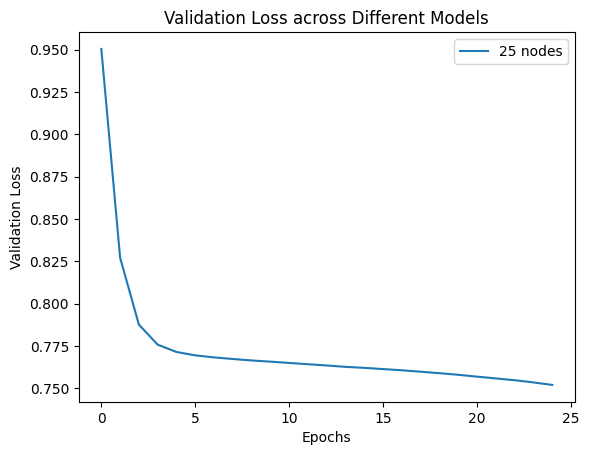

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 612us/step - accuracy: 0.4406 - loss: 1.0562 - val_accuracy: 0.5522 - val_loss: 0.9732
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 560us/step - accuracy: 0.5999 - loss: 0.9100 - val_accuracy: 0.6341 - val_loss: 0.8387
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 556us/step - accuracy: 0.6663 - loss: 0.7953 - val_accuracy: 0.6642 - val_loss: 0.7905
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 556us/step - accuracy: 0.6827 - loss: 0.7578 - val_accuracy: 0.6711 - val_loss: 0.7764
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 584us/step - accuracy: 0.6856 - loss: 0.7452 - val_accuracy: 0.6735 - val_loss: 0.7712
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 552us/step - accuracy: 0.6889 - loss: 0.7394 - val_accuracy: 0.6732 - val_loss: 0.7687
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 561us/step - accuracy: 0.6912 - loss: 0.7362 - val_accuracy: 0.6750 - val_loss: 0.7668
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 574us/step - accuracy: 0.6916 -

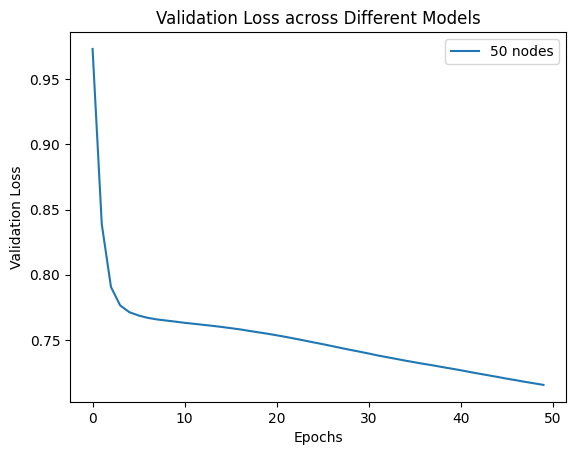

Epoch 1/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 601us/step - accuracy: 0.4536 - loss: 1.0530 - val_accuracy: 0.5566 - val_loss: 0.9756
Epoch 2/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 549us/step - accuracy: 0.5916 - loss: 0.9208 - val_accuracy: 0.6276 - val_loss: 0.8543
Epoch 3/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 549us/step - accuracy: 0.6604 - loss: 0.8092 - val_accuracy: 0.6604 - val_loss: 0.7962
Epoch 4/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - accuracy: 0.6815 - loss: 0.7627 - val_accuracy: 0.6688 - val_loss: 0.7788
Epoch 5/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step - accuracy: 0.6870 - loss: 0.7478 - val_accuracy: 0.6707 - val_loss: 0.7729
Epoch 6/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 568us/step - accuracy: 0.6897 - loss: 0.7417 - val_accuracy: 0.6731 - val_loss: 0.7704
Epoch 7/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 573us/step - accuracy: 0.6913 - loss: 0.7385 - val_accuracy: 0.6730 - val_loss: 0.7690
Epoch 8/65
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 557us/step - accuracy: 0.6910 -

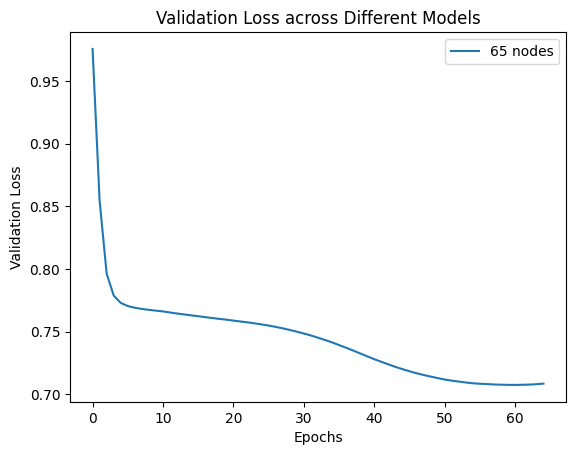

Epoch 1/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 595us/step - accuracy: 0.4367 - loss: 1.0571 - val_accuracy: 0.5512 - val_loss: 0.9741
Epoch 2/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step - accuracy: 0.5963 - loss: 0.9176 - val_accuracy: 0.6437 - val_loss: 0.8390
Epoch 3/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step - accuracy: 0.6645 - loss: 0.8002 - val_accuracy: 0.6650 - val_loss: 0.7888
Epoch 4/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step - accuracy: 0.6806 - loss: 0.7600 - val_accuracy: 0.6696 - val_loss: 0.7757
Epoch 5/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 551us/step - accuracy: 0.6875 - loss: 0.7467 - val_accuracy: 0.6723 - val_loss: 0.7715
Epoch 6/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - accuracy: 0.6899 - loss: 0.7406 - val_accuracy: 0.6730 - val_loss: 0.7697
Epoch 7/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step - accuracy: 0.6913 - loss: 0.7373 - val_accuracy: 0.6742 - val_loss: 0.7685
Epoch 8/80
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 552us/step - accuracy: 0.6914 -

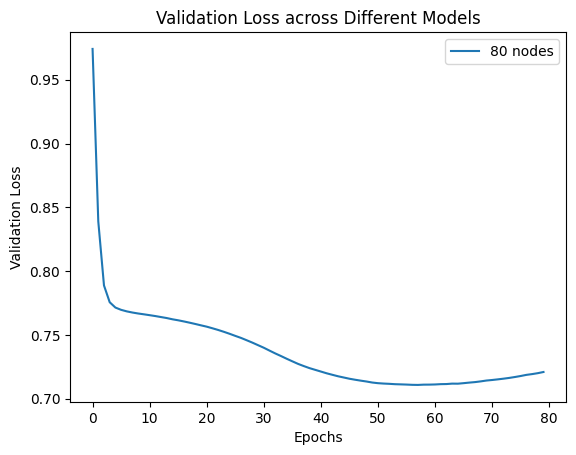

In [63]:
num_epochs = [10, 25, 50, 65, 80]
for i in num_epochs:
    model_multi_node = build_model(32, 'relu', 'softmax', 0)
    history = model_multi_node.fit(X_train, y_train, epochs=i, validation_data=(X_valid, y_valid))
    plt.plot(history.history['val_loss'], label=f'{i} nodes')
    plt.xlabel('Epochs')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss across Different Models')
    plt.legend()
    plt.show()


    


In [ ]:
# With our testing, we concluded that the number of epochs needed had to be very high when using a lower number of nodes. We did not see any increase in the validation loss until 
# the number of nodes was increased to atleast 32 and 80 epochs which can be observed in the graphs above. This led us to use around 50 epochs when testing with the various number of nodes
# to look for overfitting. Using 1, 2, 4, 8, 16 nodes with less then 80 epochs did not show an increase after the initial decrease of the validation loss. Only using a higher number nodes, 
# 32 and 80 epochs did we see an increase. We decided to use 50 for the rest of the tests with the number of nodes.

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 617us/step - accuracy: 0.3978 - loss: 1.0768 - val_accuracy: 0.4207 - val_loss: 1.0773
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 531us/step - accuracy: 0.4141 - loss: 1.0651 - val_accuracy: 0.4312 - val_loss: 1.0749
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 524us/step - accuracy: 0.4528 - loss: 1.0567 - val_accuracy: 0.5319 - val_loss: 1.0361
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - accuracy: 0.5616 - loss: 1.0026 - val_accuracy: 0.5735 - val_loss: 0.9659
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 571us/step - accuracy: 0.5958 - loss: 0.9313 - val_accuracy: 0.5874 - val_loss: 0.9224
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step - accuracy: 0.6086 - loss: 0.8935 - val_accuracy: 0.5944 - val_loss: 0.9043
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - accuracy: 0.6140 - loss: 0.8778 - val_accuracy: 0.5977 - val_loss: 0.8961
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step - accuracy: 0.6169 -

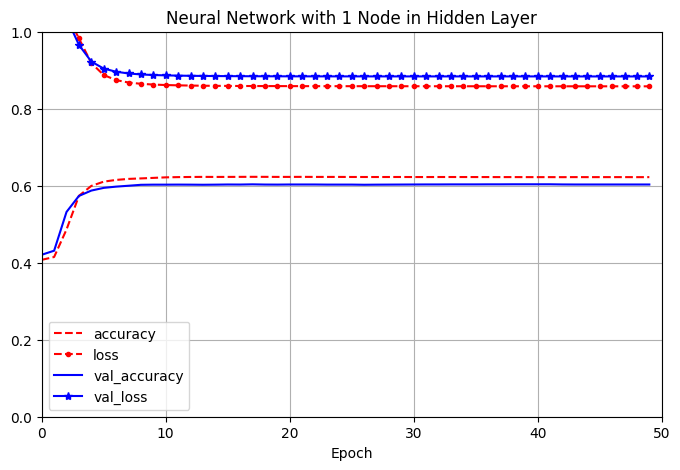

In [ ]:
# Single Node in the Hidden Layer
model_single_node = build_model(1, 'relu', 'softmax', 0)
history = model_single_node.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 1 Node in the Hidden Layer")
plt.show()

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 604us/step - accuracy: 0.4313 - loss: 1.0643 - val_accuracy: 0.5001 - val_loss: 1.0134
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step - accuracy: 0.5390 - loss: 0.9692 - val_accuracy: 0.5481 - val_loss: 0.9373
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 527us/step - accuracy: 0.5664 - loss: 0.9048 - val_accuracy: 0.5604 - val_loss: 0.9104
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 527us/step - accuracy: 0.5753 - loss: 0.8849 - val_accuracy: 0.5708 - val_loss: 0.9004
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 529us/step - accuracy: 0.5859 - loss: 0.8754 - val_accuracy: 0.5779 - val_loss: 0.8906
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 526us/step - accuracy: 0.5946 - loss: 0.8631 - val_accuracy: 0.5828 - val_loss: 0.8715
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 542us/step - accuracy: 0.6062 - loss: 0.8394 - val_accuracy: 0.6133 - val_loss: 0.8406
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 551us/step - accuracy: 0.6496 -

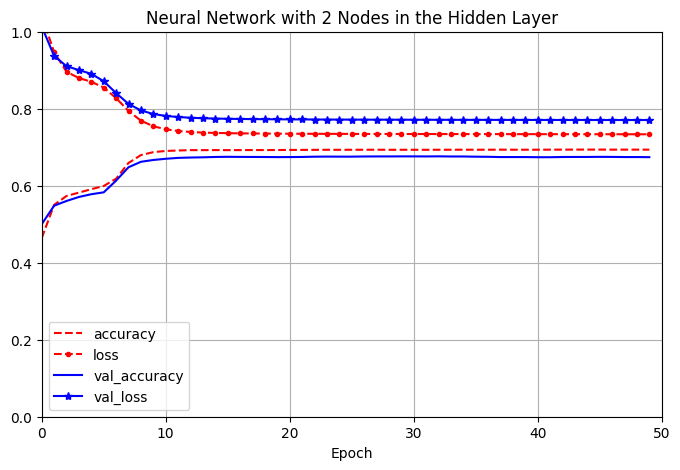

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 612us/step - accuracy: 0.4428 - loss: 1.0598 - val_accuracy: 0.5561 - val_loss: 0.9717
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 570us/step - accuracy: 0.5886 - loss: 0.9192 - val_accuracy: 0.6122 - val_loss: 0.8630
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step - accuracy: 0.6453 - loss: 0.8233 - val_accuracy: 0.6564 - val_loss: 0.8058
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step - accuracy: 0.6767 - loss: 0.7747 - val_accuracy: 0.6682 - val_loss: 0.7829
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step - accuracy: 0.6850 - loss: 0.7547 - val_accuracy: 0.6728 - val_loss: 0.7752
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 541us/step - accuracy: 0.6877 - loss: 0.7466 - val_accuracy: 0.6726 - val_loss: 0.7724
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 578us/step - accuracy: 0.6897 - loss: 0.7426 - val_accuracy: 0.6734 - val_loss: 0.7710
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 590us/step - accuracy: 0.6915 -

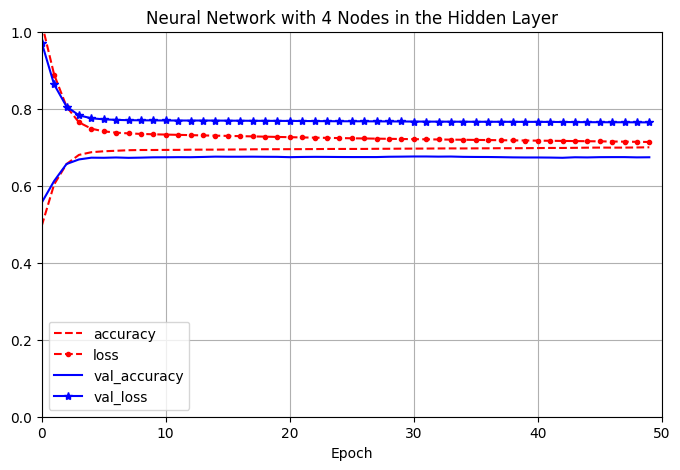

In [57]:
model_two_node = build_model(2, 'relu', 'softmax', 0)
history = model_two_node.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 2 Nodes in the Hidden Layer")
plt.show()

model_four_node = build_model(4, 'relu', 'softmax', 0)
history = model_four_node.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left") 
plt.title("Neural Network with 4 Nodes in the Hidden Layer")
plt.show()

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 592us/step - accuracy: 0.4486 - loss: 1.0515 - val_accuracy: 0.5581 - val_loss: 0.9662
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step - accuracy: 0.6060 - loss: 0.9015 - val_accuracy: 0.6379 - val_loss: 0.8413
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step - accuracy: 0.6641 - loss: 0.7966 - val_accuracy: 0.6646 - val_loss: 0.7939
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step - accuracy: 0.6804 - loss: 0.7600 - val_accuracy: 0.6684 - val_loss: 0.7795
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step - accuracy: 0.6855 - loss: 0.7474 - val_accuracy: 0.6693 - val_loss: 0.7741
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 542us/step - accuracy: 0.6879 - loss: 0.7421 - val_accuracy: 0.6704 - val_loss: 0.7716
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step - accuracy: 0.6901 - loss: 0.7392 - val_accuracy: 0.6719 - val_loss: 0.7701
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 531us/step - accuracy: 0.6905 -

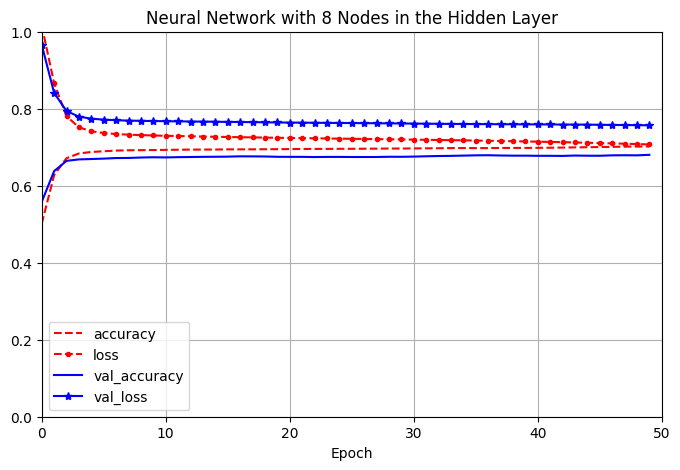

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 605us/step - accuracy: 0.4502 - loss: 1.0500 - val_accuracy: 0.5642 - val_loss: 0.9578
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step - accuracy: 0.5976 - loss: 0.9022 - val_accuracy: 0.6363 - val_loss: 0.8404
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step - accuracy: 0.6603 - loss: 0.8016 - val_accuracy: 0.6596 - val_loss: 0.7918
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 513us/step - accuracy: 0.6817 - loss: 0.7620 - val_accuracy: 0.6707 - val_loss: 0.7765
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 513us/step - accuracy: 0.6870 - loss: 0.7478 - val_accuracy: 0.6718 - val_loss: 0.7713
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 520us/step - accuracy: 0.6897 - loss: 0.7418 - val_accuracy: 0.6736 - val_loss: 0.7691
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 519us/step - accuracy: 0.6908 - loss: 0.7384 - val_accuracy: 0.6731 - val_loss: 0.7680
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 526us/step - accuracy: 0.6911 -

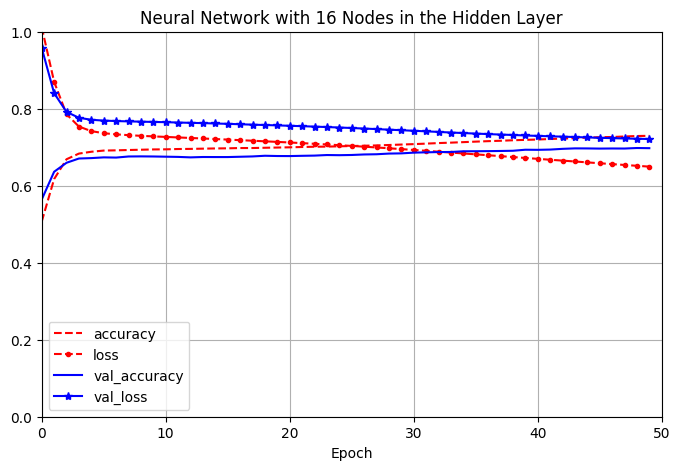

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 603us/step - accuracy: 0.4526 - loss: 1.0508 - val_accuracy: 0.5569 - val_loss: 0.9679
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step - accuracy: 0.6055 - loss: 0.9055 - val_accuracy: 0.6423 - val_loss: 0.8416
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step - accuracy: 0.6673 - loss: 0.7961 - val_accuracy: 0.6618 - val_loss: 0.7929
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 538us/step - accuracy: 0.6817 - loss: 0.7590 - val_accuracy: 0.6695 - val_loss: 0.7781
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 557us/step - accuracy: 0.6870 - loss: 0.7466 - val_accuracy: 0.6718 - val_loss: 0.7726
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step - accuracy: 0.6887 - loss: 0.7411 - val_accuracy: 0.6728 - val_loss: 0.7701
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 544us/step - accuracy: 0.6901 - loss: 0.7379 - val_accuracy: 0.6732 - val_loss: 0.7686
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 542us/step - accuracy: 0.6907 -

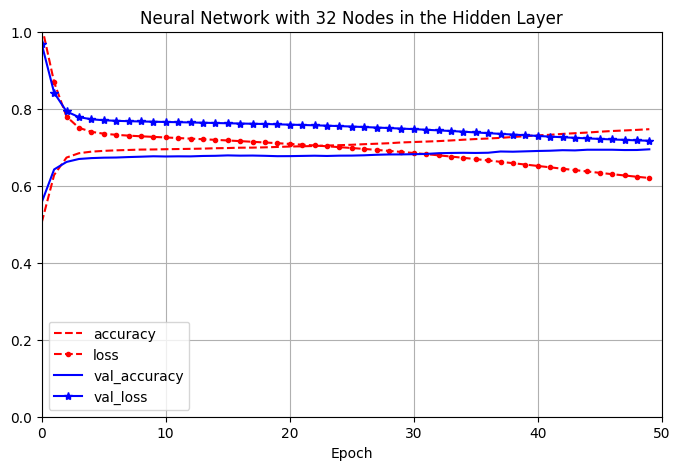

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 617us/step - accuracy: 0.4338 - loss: 1.0558 - val_accuracy: 0.5402 - val_loss: 0.9866
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 560us/step - accuracy: 0.5943 - loss: 0.9286 - val_accuracy: 0.6430 - val_loss: 0.8453
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 554us/step - accuracy: 0.6629 - loss: 0.8044 - val_accuracy: 0.6631 - val_loss: 0.7901
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 554us/step - accuracy: 0.6803 - loss: 0.7616 - val_accuracy: 0.6705 - val_loss: 0.7749
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 582us/step - accuracy: 0.6887 - loss: 0.7472 - val_accuracy: 0.6724 - val_loss: 0.7699
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 556us/step - accuracy: 0.6903 - loss: 0.7409 - val_accuracy: 0.6742 - val_loss: 0.7678
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 555us/step - accuracy: 0.6924 - loss: 0.7373 - val_accuracy: 0.6746 - val_loss: 0.7666
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 559us/step - accuracy: 0.6939 -

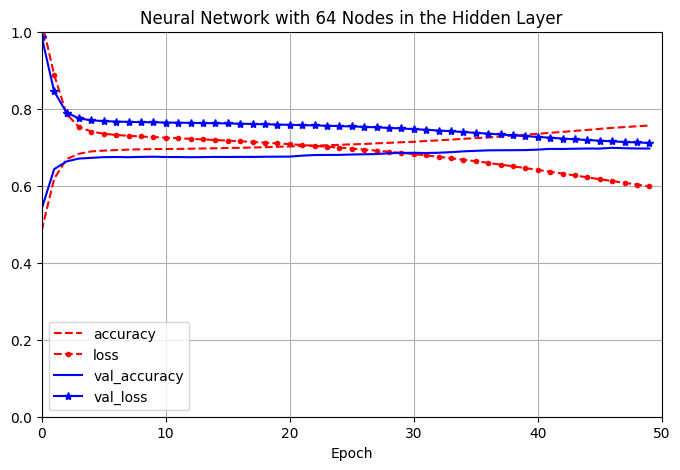

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - accuracy: 0.4419 - loss: 1.0508 - val_accuracy: 0.5740 - val_loss: 0.9603
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 590us/step - accuracy: 0.6087 - loss: 0.9017 - val_accuracy: 0.6466 - val_loss: 0.8281
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 595us/step - accuracy: 0.6689 - loss: 0.7901 - val_accuracy: 0.6672 - val_loss: 0.7843
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 592us/step - accuracy: 0.6841 - loss: 0.7550 - val_accuracy: 0.6713 - val_loss: 0.7729
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 591us/step - accuracy: 0.6890 - loss: 0.7432 - val_accuracy: 0.6709 - val_loss: 0.7692
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 593us/step - accuracy: 0.6911 - loss: 0.7377 - val_accuracy: 0.6722 - val_loss: 0.7675
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 608us/step - accuracy: 0.6919 - loss: 0.7341 - val_accuracy: 0.6735 - val_loss: 0.7664
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 597us/step - accuracy: 0.6931 -

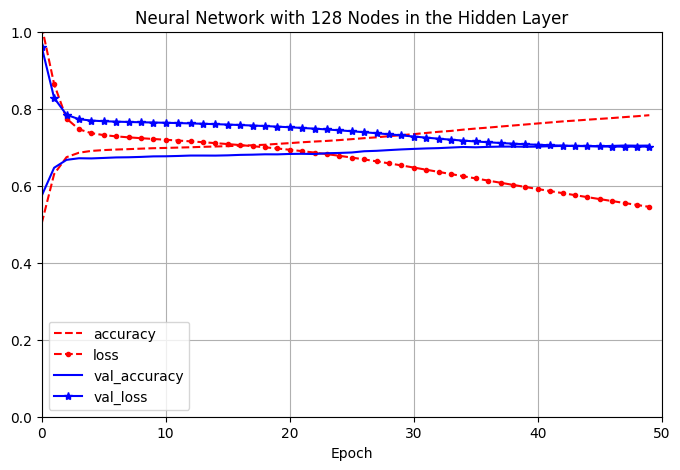

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 779us/step - accuracy: 0.4809 - loss: 1.0340 - val_accuracy: 0.5850 - val_loss: 0.9344
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step - accuracy: 0.6255 - loss: 0.8766 - val_accuracy: 0.6456 - val_loss: 0.8194
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step - accuracy: 0.6715 - loss: 0.7821 - val_accuracy: 0.6645 - val_loss: 0.7821
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 722us/step - accuracy: 0.6845 - loss: 0.7516 - val_accuracy: 0.6707 - val_loss: 0.7715
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step - accuracy: 0.6883 - loss: 0.7403 - val_accuracy: 0.6743 - val_loss: 0.7677
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 718us/step - accuracy: 0.6913 - loss: 0.7345 - val_accuracy: 0.6751 - val_loss: 0.7659
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.6941 - loss: 0.7307 - val_accuracy: 0.6763 - val_loss: 0.7647
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step - accuracy: 0.6944 -

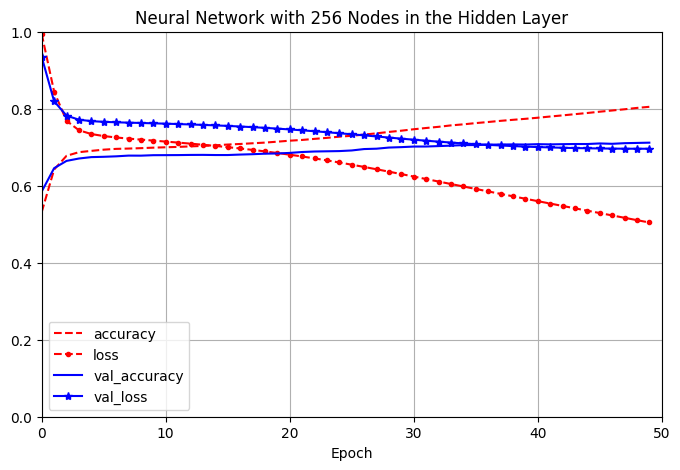

Epoch 1/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 874us/step - accuracy: 0.4775 - loss: 1.0344 - val_accuracy: 0.5950 - val_loss: 0.9337
Epoch 2/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step - accuracy: 0.6356 - loss: 0.8725 - val_accuracy: 0.6527 - val_loss: 0.8165
Epoch 3/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 829us/step - accuracy: 0.6759 - loss: 0.7776 - val_accuracy: 0.6673 - val_loss: 0.7808
Epoch 4/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 813us/step - accuracy: 0.6859 - loss: 0.7490 - val_accuracy: 0.6726 - val_loss: 0.7708
Epoch 5/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 813us/step - accuracy: 0.6910 - loss: 0.7384 - val_accuracy: 0.6746 - val_loss: 0.7671
Epoch 6/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 818us/step - accuracy: 0.6937 - loss: 0.7330 - val_accuracy: 0.6750 - val_loss: 0.7654
Epoch 7/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 1s 812us/step - accuracy: 0.6952 - loss: 0.7293 - val_accuracy: 0.6749 - val_loss: 0.7643
Epoch 8/50
1822/1822 ━━━━━━━━━━━━━━━━━━━━ 2s 820us/step - accuracy: 0.6968 -

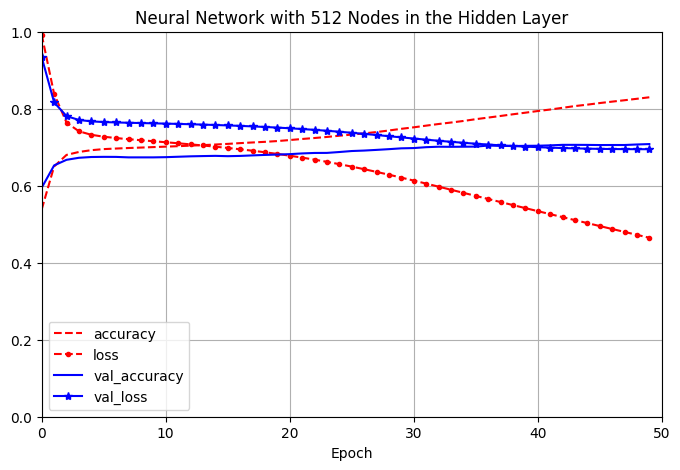

In [58]:
num_nodes = [8, 16, 32, 64, 128, 256, 512]

for i in num_nodes:
    model_multi_node = build_model(i, 'relu', 'softmax', 0)
    history = model_multi_node.fit(X_train, y_train, epochs=50, validation_data=(X_valid, y_valid))

    pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
    plt.legend(loc="lower left") 
    plt.title(f"Neural Network with {i} Nodes in the Hidden Layer")
    plt.show()


In [ ]:
# When using 8 and 16 nodes in the hidden layer,
# we can observe that the validation loss decreases and then flattens out and becomes stable
# this implies that there is underfitting

# When using 32 and 64 nodes in the hidden layer,
# we can observe that the validation loss as well as the training loss decrease
# to lower than when we tried 8 and 16 nodes
# The accuracy in this case also improves much more
# it seems that around the 32 and 64 range is the optimal number of nodes for our use case

# When using 128, 256, and 512 nodes in the hidden layer,
# we can observe that the validation loss slightly increases and the training loss decreases
# this can be a sign of overfitting since the model is overfitting to the training set
# and performing worse on the validation set

    - **Varying the number of layers**.

        - Conduct similar experiments as described above, but this time vary the number of layers from 1 to 4. Document your findings.

        - How many nodes should each layer contain? Test at least two scenarios. Traditionally, a common strategy involved decreasing the number of nodes from the input layer to the output layer, often by halving, to create a pyramid-like structure. However, recent experience suggests that maintaining a constant number of nodes across all layers can perform equally well. Describe your observations. It is acceptable if both strategies yield similar performance results.

        - Select one your models that exemplifies overfitting. In our experiments, we easily constructed a model achieving nearly 100% accuracy on the training data, yet showing no similar improvement on the validation set. Present this neural network along with its accuracy and loss graphs. Explain the reasoning for concluding that the model is overfitting.

In [ ]:
# Code cell

    - **Activation function**.

        - Present results for one of the configurations mentioned above by varying the activation function. Test at least `relu` (the default) and `sigmoid`. The choice of the specific model, including the number of layers and nodes, is at your discretion. Document your observations accordingly.

In [ ]:
# Code cell

    - **Regularization** in neural networks is a technique used to prevent overfitting.

        - One technique involves adding a penalty to the loss function to discourage excessively complex models. Apply an `l2` penalty to some or all layers. Exercise caution, as overly aggressive penalties have been problematic in our experiments. Begin with the default `l2` value of 0.01, then reduce it to 0.001 and 1e-4. Select a specific model from the above experiments and present a case where you successfully reduced overfitting. Include a pair of graphs comparing results with and without regularization. Explain your rationale to conclude that overfitting has been reduced. Do not expect to completely eliminate overfitting. Again, this is a challenging dataset to work with.

In [ ]:
# Code cell

        - Dropout layers are a regularization technique in neural networks where a random subset of neurons is temporarily removed during training. This helps prevent overfitting by promoting redundancy and improving the network's ability to generalize to new data. Select a specific model from the above experiments where you have muliple layers and experiment adding one or of few dropout layers into your network. Experiment with two different rates, say 0.25 and 0.5. Document your observations.

In [ ]:
# Code cell

        - Summarize your experiments with using a graphical representation such as Figure 6.15 [on this page](https://egallic.fr/Enseignement/ML/ECB/book/deep-learning.html).

In [ ]:
# Code cell

        - Early stopping is a regularization technique in neural network training wherein the process is halted when validation set performance starts to decline, thus preventing overfitting by avoiding the learning of noise in the training data. From all the experiments conducted thus far, choose **one** configuration (the number of layers, number of nodes, activation function, L2 penalty, and dropout layers) that yielded the best performance. Use a graph of loss and accuracy to determine the optimal number of training iterations for this network. What is the optimal number of epochs for this network configuration and why?

In [ ]:
# Code cell

### Test

9. **Model Comparison**:

    - Evaluate the baseline model on the test set, using the optimal parameter set identified through grid search. Additionally, apply your best-performing neural network configuration to the test set.

    - Quantify the performance of the baseline model (best hyperparameter configuration) and your neural network (best configuration) using precision, recall, and F1-score as metrics. How do these two models compare to the dummy model?

    - Provide recommendations on which model(s) to choose for this task and justify your choices based on the analysis results.

In [ ]:
# Code cell

# Resources